<a href="https://colab.research.google.com/github/Iffraah96/ShopSense-AI/blob/main/notebook/05_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ShopSense AI

## Notebook 5: Model Training

### Objective

Following are the steps to be carried out in this notebook:

Import libraries
Load the processed data / TF-IDF features
Prepare X_train, X_test, y_train, y_test
Train a baseline model — Logistic Regression
Make predictions
Evaluate accuracy, precision, recall, and F1-score
Create a confusion matrix
Examine important features
Train a second model for comparison
Compare models
Save the best model

## Import Libraries

In [19]:
# General Libraries
import pandas as pd
import numpy as np

# import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Metrics for evaluating the model
from sklearn.model_selection import train_test_split
from sklearn.metrics import ( accuracy_score,
 precision_score,
 recall_score,
 f1_score,
 confusion_matrix
)

# Used later to visualize the confusion matrix
import matplotlib.pyplot as plt

# Used to save and load our trained model
import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Dataset

In [4]:
# Load the processed dataset from Notebook 3
df = pd.read_csv("/content/nlp_preprocessed_women_clothing_review_dataset.csv")

# Check that the dataset loaded correctly
print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (22641, 15)


,clothing_id,age,title,review_text,rating,recommended_ind,positive_feedback_count,division_name,department_name,class_name,cleaned_review,tokens,tokens_without_stopwords,lemmatized_tokens,final_cleaned_review
0,767,33,No Title,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,absolutely wonderful silky and sexy and comfor...,"['absolutely', 'wonderful', 'silky', 'and', 's...","['absolutely', 'wonderful', 'silky', 'sexy', '...","['absolutely', 'wonderful', 'silky', 'sexy', '...",absolutely wonderful silky sexy comfortable
1,1080,34,No Title,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,love this dress it's sooo pretty i happened to...,"['love', 'this', 'dress', ""it's"", 'sooo', 'pre...","['love', 'dress', ""it's"", 'sooo', 'pretty', 'h...","['love', 'dress', ""it's"", 'sooo', 'pretty', 'h...",love dress it's sooo pretty happened find stor...
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,i had such high hopes for this dress and reall...,"['i', 'had', 'such', 'high', 'hopes', 'for', '...","['high', 'hopes', 'dress', 'really', 'wanted',...","['high', 'hope', 'dress', 'really', 'wanted', ...",high hope dress really wanted work initially o...
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,i love love love this jumpsuit it's fun flirty...,"['i', 'love', 'love', 'love', 'this', 'jumpsui...","['love', 'love', 'love', 'jumpsuit', ""it's"", '...","['love', 'love', 'love', 'jumpsuit', ""it's"", '...",love love love jumpsuit it's fun flirty fabulo...
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,this shirt is very flattering to all due to th...,"['this', 'shirt', 'is', 'very', 'flattering', ...","['shirt', 'flattering', 'due', 'adjustable', '...","['shirt', 'flattering', 'due', 'adjustable', '...",shirt flattering due adjustable front tie perf...


## Load the Saved TF-IDF Vectorizer

In [5]:
# Load the TF-IDF vectorizer created in Notebook 4
tfidf = joblib.load("shopsense_tfidf_vectorizer.pkl")

# Check that the vectorizer loaded correctly
print("TF-IDF vectorizer loaded successfully!")

# Check the number of features
print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))

TF-IDF vectorizer loaded successfully!
Number of TF-IDF features: 5000


## Prepare X and y

In [6]:
# Select the column 'final_cleaned_review'
X = df["final_cleaned_review"]

# Select the target variable
# 1 = recommended
# 0 = not recommended
y = df["recommended_ind"]

# Check the data
print("Number of reviews:", len(X))
print("Number of target values:", len(y))

# Check for missing values
print("\nMissing review values:", X.isna().sum())
print("Missing target values:", y.isna().sum())

Number of reviews: 22641
Number of target values: 22641

Missing review values: 0
Missing target values: 0


## Recreate the Same Train/Test Split

In [7]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,       # 20% for testing
    random_state=42,      # Same random state as Notebook 4
    stratify=y            # Keep the same class distribution
)

# Check the sizes
print("Training reviews:", X_train.shape)
print("Testing reviews:", X_test.shape)

# Check the target distribution
print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training reviews: (18112,)
Testing reviews: (4529,)

Training target distribution:
recommended_ind
1    14831
0     3281
Name: count, dtype: int64

Testing target distribution:
recommended_ind
1    3709
0     820
Name: count, dtype: int64


## Transform the reviews using our saved 5,000-feature TF-IDF vectorizer.

In [8]:
# Transform the training reviews using the saved TF-IDF vectorizer
X_train_tfidf = tfidf.transform(X_train)

# Transform the testing reviews using the same vectorizer
X_test_tfidf = tfidf.transform(X_test)

# Check the shape of the TF-IDF matrices
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (18112, 5000)
Testing TF-IDF shape: (4529, 5000)


## Train the Logistic Regression Model

In [9]:
# Create the Logistic Regression model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using the TF-IDF training features
model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## Make Predictions on the Test Data

In [10]:
# Use the trained model to predict the test reviews
y_pred = model.predict(X_test_tfidf)

# Display the first 20 predictions
print("First 20 predictions:")
print(y_pred[:20])

# Compare the number of predictions with the actual test labels
print("\nNumber of predictions:", len(y_pred))
print("Number of actual labels:", len(y_test))

First 20 predictions:
[1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Number of predictions: 4529
Number of actual labels: 4529


## Evaluate the Model

Now we'll measure how well our Logistic Regression model performed on the unseen test reviews.

We'll calculate four important metrics:

Accuracy — overall percentage of correct predictions
Precision — when the model predicts "recommended," how often is it correct?
Recall — how many of the actually recommended products did the model identify?
F1-score — balance between precision and recall

In [11]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display the results
print("Logistic Regression Results")
print("=" * 35)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Logistic Regression Results
Accuracy:  0.8867
Precision: 0.9011
Recall:    0.9679
F1-score:  0.9333


## Classification Report

In [13]:
from sklearn.metrics import classification_report

# Generate a detailed classification report
print("Classification Report")
print("=" * 60)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Recommended", "Recommended"]
))

Classification Report
                 precision    recall  f1-score   support

Not Recommended       0.78      0.52      0.62       820
    Recommended       0.90      0.97      0.93      3709

       accuracy                           0.89      4529
      macro avg       0.84      0.74      0.78      4529
   weighted avg       0.88      0.89      0.88      4529



## Create the Confusion Matri

In [14]:
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix values
print("Confusion Matrix")
print(cm)

Confusion Matrix
[[ 426  394]
 [ 119 3590]]


## Visualize the Confusion Matrix

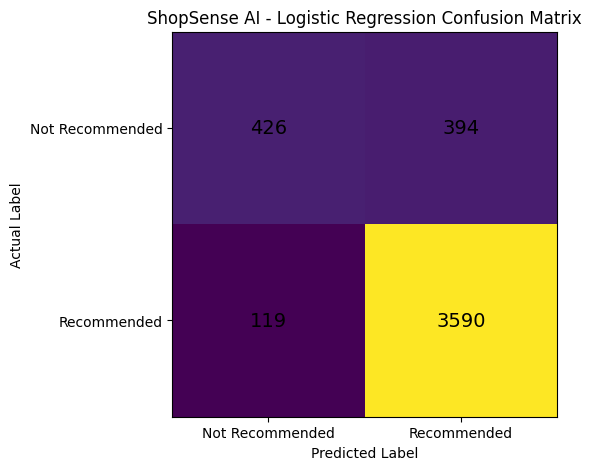

In [15]:
# Create a visual confusion matrix
plt.figure(figsize=(6, 5))

plt.imshow(cm)

# Add the values inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 fontsize=14)

# Add labels
plt.xticks(
    [0, 1],
    ["Not Recommended", "Recommended"]
)

plt.yticks(
    [0, 1],
    ["Not Recommended", "Recommended"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("ShopSense AI - Logistic Regression Confusion Matrix")

plt.show()

## Identify Important Features

Logistic Regression assigns a coefficient to every TF-IDF feature.

Positive coefficient → pushes the prediction toward Recommended (1)
Negative coefficient → pushes the prediction toward Not Recommended (0)
The larger the absolute value, the stronger the feature's influence.

In [17]:
# Get the feature names from our saved TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()

# Get the coefficients learned by Logistic Regression
coefficients = model.coef_[0]

# Create a table connecting each feature with its coefficient
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Sort features by their coefficient
# Most negative = strongest toward Not Recommended
# Most positive = strongest toward Recommended
feature_importance = feature_importance.sort_values(
    by="coefficient"
)

# Display the 15 strongest features for Not Recommended
print("Top features associated with Not Recommended:")
display(feature_importance.head(15))

# Display the 15 strongest features for Recommended
print("\nTop features associated with Recommended:")
display(feature_importance.tail(15).sort_values(by="coefficient", ascending=False))

Top features associated with Not Recommended:


,feature,coefficient
1081,disappointed,-5.485022
4670,wanted love,-4.862974
3533,returned,-4.712249
3535,returning,-4.495265
2891,not flattering,-4.039651
677,cheap,-3.992814
4568,unflattering,-3.800434
1762,going back,-3.499455
3531,return,-3.331588
333,bad,-3.274634



Top features associated with Recommended:


,feature,coefficient
2493,love,5.558653
3158,perfect,4.682577
795,comfortable,4.051703
1823,great,3.925892
2362,little,3.467783
4012,soft,3.252962
4574,unique,3.040732
838,compliment,3.024512
1594,flattering,2.817603
434,bit,2.660191


## Save the Trained Logistic Regression Model

In [18]:
# Save the trained Logistic Regression model
joblib.dump(model, "shopsense_logistic_regression.pkl")

print("Logistic Regression model saved successfully!")

Logistic Regression model saved successfully!


## Train Linear SVM

In [20]:
# Create the Linear SVM model
svm_model = LinearSVC(
    random_state=42
)

# Train the model using the TF-IDF training features
svm_model.fit(X_train_tfidf, y_train)

print("Linear SVM model trained successfully!")

Linear SVM model trained successfully!


## Make Predictions with Linear SVM

In [21]:
# Use the trained Linear SVM model to predict the test reviews
svm_pred = svm_model.predict(X_test_tfidf)

# Check the number of predictions
print("Number of SVM predictions:", len(svm_pred))

# Display the first 20 predictions
print("\nFirst 20 SVM predictions:")
print(svm_pred[:20])

Number of SVM predictions: 4529

First 20 SVM predictions:
[1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


## Evaluate Linear SVM

In [22]:
# Calculate evaluation metrics for Linear SVM
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

# Display the results
print("Linear SVM Results")
print("=" * 35)

print(f"Accuracy:  {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1-score:  {svm_f1:.4f}")

Linear SVM Results
Accuracy:  0.8865
Precision: 0.9179
Recall:    0.9461
F1-score:  0.9318


## SVM Classification Report

In [23]:
# Generate a detailed classification report for Linear SVM
print("Linear SVM Classification Report")
print("=" * 60)

print(classification_report(
    y_test,
    svm_pred,
    target_names=["Not Recommended", "Recommended"]
))

Linear SVM Classification Report
                 precision    recall  f1-score   support

Not Recommended       0.72      0.62      0.66       820
    Recommended       0.92      0.95      0.93      3709

       accuracy                           0.89      4529
      macro avg       0.82      0.78      0.80      4529
   weighted avg       0.88      0.89      0.88      4529



## SVM Confusion Matrix

In [24]:
# Create the confusion matrix for Linear SVM
svm_cm = confusion_matrix(y_test, svm_pred)

# Display the confusion matrix values
print("Linear SVM Confusion Matrix")
print(svm_cm)

Linear SVM Confusion Matrix
[[ 506  314]
 [ 200 3509]]


## Save the SVM Model

In [25]:
# Save the trained Linear SVM model
joblib.dump(svm_model, "shopsense_linear_svm.pkl")

print("Linear SVM model saved successfully!")

Linear SVM model saved successfully!


## Compare Both Models

In [26]:
# Create a comparison table for our two models
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy,
        svm_accuracy
    ],
    "Precision": [
        precision,
        svm_precision
    ],
    "Recall": [
        recall,
        svm_recall
    ],
    "F1-score": [
        f1,
        svm_f1
    ]
})

# Display the comparison table
display(model_comparison)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.886730,0.901104,0.967916,0.933316
1,Linear SVM,0.886509,0.917866,0.946077,0.931758


## A function for predicting new customer reviews with confidence

The function will:

Accept a new customer review
Apply our saved TF-IDF transformation
Send the numerical features to Logistic Regression
Return Recommended or Not Recommended

In [30]:
# Create a prediction function that also returns confidence
def predict_recommendation_with_confidence(review):
    # Convert the new review into TF-IDF features
    review_tfidf = tfidf.transform([review])

    # Get the predicted class
    prediction = model.predict(review_tfidf)[0]

    # Get the probability for each class
    probabilities = model.predict_proba(review_tfidf)[0]

    # Get the probability of the predicted class
    confidence = probabilities[prediction]

    # Convert the prediction into a readable label
    if prediction == 1:
        result = "Recommended"
    else:
        result = "Not Recommended"

    return result, confidence

## Test ShopSense with a New Review

In [31]:
# Test ShopSense with a new customer review
new_review = "I absolutely love this dress. The fabric is soft and the fit is perfect."

# Get the prediction and confidence
prediction, confidence = predict_recommendation_with_confidence(new_review)

print("Review:")
print(new_review)

print("\nShopSense AI Prediction:")
print(prediction)

print(f"Confidence: {confidence:.2%}")

Review:
I absolutely love this dress. The fabric is soft and the fit is perfect.

ShopSense AI Prediction:
Recommended
Confidence: 99.65%


## Test a Negative Review

In [32]:
# Test ShopSense with a negative customer review
negative_review = "I was disappointed with this dress. The fabric feels cheap and the fit is unflattering, so I returned it."

# Get the prediction and confidence
prediction, confidence = predict_recommendation_with_confidence(negative_review)

print("Review:")
print(negative_review)

print("\nShopSense AI Prediction:")
print(prediction)

print(f"Confidence: {confidence:.2%}")

Review:
I was disappointed with this dress. The fabric feels cheap and the fit is unflattering, so I returned it.

ShopSense AI Prediction:
Not Recommended
Confidence: 99.89%


##Test a Mixed Review

In [33]:
# Test ShopSense with a mixed customer review
mixed_review = "The dress is beautiful and the fabric is soft, but the fit is a little tight and uncomfortable."

# Get the prediction and confidence
prediction, confidence = predict_recommendation_with_confidence(mixed_review)

print("Review:")
print(mixed_review)

print("\nShopSense AI Prediction:")
print(prediction)

print(f"Confidence: {confidence:.2%}")

Review:
The dress is beautiful and the fabric is soft, but the fit is a little tight and uncomfortable.

ShopSense AI Prediction:
Recommended
Confidence: 93.86%


## Save the Final ShopSense Components

In [34]:
# Save the final Logistic Regression model
joblib.dump(model, "shopsense_final_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(tfidf, "shopsense_final_tfidf.pkl")

print("Final ShopSense model saved successfully!")
print("Final TF-IDF vectorizer saved successfully!")

Final ShopSense model saved successfully!
Final TF-IDF vectorizer saved successfully!


## Final Model Performance Summary

In [35]:
# Create a final performance summary
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy,
        svm_accuracy
    ],
    "Precision": [
        precision,
        svm_precision
    ],
    "Recall": [
        recall,
        svm_recall
    ],
    "F1-score": [
        f1,
        svm_f1
    ]
})

# Round the metrics for easier reading
final_results[["Accuracy", "Precision", "Recall", "F1-score"]] = (
    final_results[["Accuracy", "Precision", "Recall", "F1-score"]]
    .round(4)
)

print("ShopSense AI - Final Model Comparison")
display(final_results)

ShopSense AI - Final Model Comparison


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.8867,0.9011,0.9679,0.9333
1,Linear SVM,0.8865,0.9179,0.9461,0.9318


## Observation:

In this notebook, the ShopSense AI text classification models were trained using TF-IDF features extracted from customer reviews. Logistic Regression was selected as the primary model and Linear SVM was used as a comparison model.

The Logistic Regression model achieved an accuracy of **88.67%**, precision of **90.11%**, recall of **96.79%**, and an F1-score of **93.33%**. These results indicate that the model performs well overall, particularly in identifying reviews where customers recommend the product.

Linear SVM achieved a similar overall performance, with an accuracy of **88.65%** and an F1-score of **93.18%**. However, Linear SVM performed better at identifying the minority **Not Recommended** class, achieving a recall of **62%** compared with **52%** for Logistic Regression.

Feature-importance analysis showed that positive terms such as **"love," "perfect," "comfortable," and "great"** strongly influenced Recommended predictions, while terms such as **"disappointed," "returned," "cheap," and "unflattering"** strongly influenced Not Recommended predictions.

Based on the overall performance, **Logistic Regression was selected as the primary ShopSense AI model**. The model was also successfully tested on new positive, negative, and mixed customer reviews, demonstrating that the trained system can classify previously unseen reviews.

Overall, this notebook successfully completed the model training and evaluation stage of the ShopSense AI pipeline. The trained model and TF-IDF vectorizer were saved for future use in prediction and application development.